<a href="https://colab.research.google.com/github/127003278/potato-leaf-disese-classification/blob/main/Xception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/ResNet50/Training"

In [ ]:
import os
os.listdir(dataset_path)

['Early_Blight', 'Late_Blight', 'Healthy']

#Image Preprocessing

In [ ]:
import tensorflow as tf
import numpy as np
#Image Preprocessing

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

Found 6000 files belonging to 3 classes.
Using 4800 files for training.


In [ ]:
print(train_ds.class_names)


['Early_Blight', 'Healthy', 'Late_Blight']


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

Found 6000 files belonging to 3 classes.
Using 1200 files for validation.


In [ ]:
from tensorflow.keras.applications.xception import preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

In [ ]:
import os

for folder in os.listdir(dataset_path):
    print(folder, len(os.listdir(dataset_path + "/" + folder)))

Early_Blight 2000
Late_Blight 2000
Healthy 2000


# Xception Training

In [ ]:
import tensorflow.keras as keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import Xception

In [ ]:
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [ ]:
from tensorflow.keras import layers, models
xceptionModel = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

In [ ]:
from tensorflow.keras.optimizers import SGD

optimizer = SGD(
    learning_rate=0.001,
    momentum=0.9
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
reduce_LR = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [ ]:
xceptionModel.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
xceptionModel.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,042,667 (84.09 MB)

 Trainable params: 1,181,187 (4.51 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
history = xceptionModel.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stopping, reduce_LR]
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 211ms/step - accuracy: 0.7071 - loss: 0.6991 - val_accuracy: 0.8400 - val_loss: 0.4411 - learning_rate: 0.0010
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step - accuracy: 0.8581 - loss: 0.3923 - val_accuracy: 0.8675 - val_loss: 0.3310 - learning_rate: 0.0010
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step - accuracy: 0.8829 - loss: 0.3187 - val_accuracy: 0.8875 - val_loss: 0.2870 - learning_rate: 0.0010
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - accuracy: 0.8963 - loss: 0.2827 - val_accuracy: 0.8975 - val_loss: 0.2602 - learning_rate: 0.0010
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 161ms/step - accuracy: 0.9069 - loss: 0.2597 - val_accuracy: 0.8967 - val_loss: 0.2529 - learning_rate: 0.0010
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 161ms/step - accuracy: 0.9110 - loss: 0.2369 - val_accuracy: 0.9067 - val_loss: 0.2326 - learning_rate: 0.0010
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - accuracy: 0.9

In [ ]:
xceptionModel.save('/content/drive/MyDrive/ResNet50/Model/xception.keras')

#Test Dataset Preprocessing

In [ ]:
from tensorflow.keras.applications.xception import preprocess_input
test_path = "/content/drive/MyDrive/ResNet50/Testing"
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 552 files belonging to 3 classes.


In [ ]:
class_names = test_ds.class_names
print(class_names)

['Early_Blight', 'Healthy', 'Late_Blight']


In [ ]:
test_ds = test_ds.map(lambda x,y: (preprocess_input(x),y))
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

#Evaluating

In [ ]:
test_loss, test_accuracy = xceptionModel.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 306ms/step - accuracy: 0.9167 - loss: 0.2127
Test Accuracy: 0.9166666865348816
Test Loss: 0.21268238127231598


#Performance Metrices

In [ ]:
import numpy as np

y_pred = xceptionModel.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x,y in test_ds], axis=0)

18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 359ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred_classes) * 100
precision = precision_score(y_true, y_pred_classes, average="weighted") * 100
recall = recall_score(y_true, y_pred_classes, average="weighted") * 100
f1 = f1_score(y_true, y_pred_classes, average="weighted") * 100

print("Accuracy: {:.2f}%".format(accuracy))
print("Precision: {:.2f}%".format(precision))
print("Recall: {:.2f}%".format(recall))
print("F1 Score: {:.2f}%".format(f1))

Accuracy: 91.67%
Precision: 92.22%
Recall: 91.67%
F1 Score: 91.72%


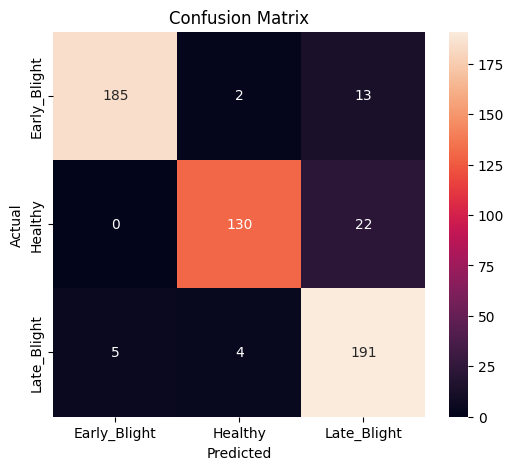

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()